# Solve the nonlinear Poisson equation 
\begin{equation} 
\begin{cases}
    - \nabla \cdot (a(u) \nabla u) = f(x), \quad x \in \Omega \\ 
    u(x) = g(x), \quad x \in \partial \Omega.  
\end{cases}
\end{equation} 
where $a(u) = u^{2} - u$ and   
solution: $u(x) = \exp\left(-\frac{1}{d} \sum_{i=1}^{d} x_{i} \right), \quad \Omega = [-1,1]^{d} $

In [2]:
import torch 
import torch.nn as nn 
from collections import OrderedDict 

import numpy as np 
import matplotlib.pyplot as plt
import scipy.io 
from scipy.interpolate import griddata 

from mpl_toolkits.axes_grid1 import make_axes_locatable 
import matplotlib.gridspec as gridspec 
import warnings 
import time 

warnings.filterwarnings('ignore') 

# np.random.seed(1234) 

In [3]:
# MPS or CUDA or CPU 
if torch.backends.mps.is_available():
    device = torch.device('mps') 
elif torch.cuda.is_available():
    device = torch.device('cuda') 
else:
    device = torch.device('cpu') 
# 
print(f"Working on {device}") 


Working on mps


# Using Random Features: 
\begin{equation}
u(x) = \sum_{k=1}^{N} c_{k} \cos(<\omega_{k}, x> + b_{k}) 
\end{equation} 

Only train the coefficients $c_{k}$

In [4]:
class Random_Four_feature(nn.Module): 
    def __init__(self, in_dim, D, sigma = 1.0):
        super().__init__() 
        # set up parameters for random features
        self.in_dim = in_dim 
        self.D = D 
        self.sigma = sigma 

        # sample omega and b, store as buffers so they move with model.to(device)
        # self.W = nn.Parameter(torch.randn(D, in_dim) * sigma, requires_grad = False) # N(0, 1 / sigma^2) (D, in_dim)           
        # self.b = nn.Parameter(2 * torch.pi * torch.rand(D, 1), requires_grad = False)  # uniform in [0, 2pi)
        self.register_buffer("W", torch.randn(D, in_dim) * sigma)
        self.register_buffer("b", 2 * torch.pi * torch.rand(D))
        

    def forward(self, x): 
        # X: (N, in_dim) 
        proj = torch.mm(x, self.W.T) # (N, D) 
        proj = proj.T # (D, N) 
        Z = torch.cos(proj + self.b)
        return Z.T  # (1, D)           

In [5]:
class Random_Feature_model(nn.Module): 
    def __init__(self, in_dim, D, sigma = 1.0, out_dim = 1): 
        super().__init__() 
        self.in_dim = in_dim 
        self.D = D 
        self.register_buffer("W", torch.randn(D, in_dim) * sigma)
        self.register_buffer("b", 2 * torch.pi * torch.rand(D, 1))

        # learn linear coefficients \alpha: map D to out_dim = 1; one hidden layer 
        self.linear = nn.Linear(D, out_dim, bias = False)
        nn.init.zeros_(self.linear.weight)
    
        # Optionally initialize linear weights small 
        # nn.init.normal_(self.linear.weight, mean = 0.0, std = 1e-3) 
        # nn.init.zeros_(self.linear.bias) 

    def forward(self, x): 
        # x must be a float tensor on the smae device as model 
        proj = torch.mm(x, self.W.T) # (N, D)  
        Z = torch.cos(proj.T + self.b) # (D, N) 
     
        return self.linear(Z.T) # (N, 1) 

# Solve the nonlinear Poisson equations: 

In [97]:
class RFN_Nonlinear_Poisson(nn.Module): 
    def __init__(self, X_train, X_bc, U_bc, lb, ub, in_dim, D, scale = 1.0, out_dim = 1):  
        super().__init__() 
        # set up parameters for random features 
        self.D = D 
        self.scale = scale
        self.in_dim = in_dim 
        
        
        # boundary conditions: domain bounds 
        self.lb = torch.as_tensor(lb, dtype = torch.float, device = device)
        self.ub = torch.as_tensor(ub, dtype = torch.float, device = device)

        # data 
        self.X_train = torch.tensor(X_train, requires_grad = True).float().to(device) # All spatial axes  

        # boundary data 
        self.X_bc = torch.tensor(X_bc).float().to(device) 
        self.U_bc = torch.tensor(U_bc).float().to(device) 
        
        # random feature model     
        self.rf = Random_Feature_model(in_dim, D, scale).to(device) 
        self.register_buffer("W", self.rf.W.clone())
        self.register_buffer("b", self.rf.b.clone())
        
        # optimizers: 
        self.optimizer = torch.optim.LBFGS( # require multiple evaluations of the loss function per iteraton
            self.rf.parameters(), # target to be optimized 
            lr = 1.0, # learning rate: step length 
            max_iter = 1, # maximum number of iterations: can be reduced 
            max_eval = 50000, # total numebr of times the closure ( loss + backward pass) can be called
            history_size = 50, 
            tolerance_grad = 1e-7, 
            tolerance_change = 1e-9,
            line_search_fn = "strong_wolfe" 
        ) 

        self.optimizer_Adam = torch.optim.Adam(self.rf.parameters(), lr = 1e-3, betas = (0.9, 0.999), weight_decay = 1.0) 
    
        self.iter = 0 
    
    def force_func(self, X): 
        f = (- 3 * torch.exp(-3 / self.in_dim * torch.sum(X, axis = 1, keepdim = True)) \
              + 2 * torch.exp(-2 / self.in_dim * torch.sum(X, axis = 1, keepdim = True))) / self.in_dim # (M,1), M: number of input data 
        return f 
    
    def net_u(self, X): # predicted value 
        u = self.rf(X) # High-dimensional input 
        return u 

    def PDE_residual(self, X): 
        """ The pytorch autograd version of calculating residual """
        u = self.net_u(X) 
        
        force = self.force_func(X) # force term values at these points (x,y)  
         
       
        # PDE residual loss 
        grad_u = torch.autograd.grad(u, X, grad_outputs = torch.ones_like(u), create_graph = True, retain_graph = True)[0] # (batch, dim) # To get the actual gradient tensor from the output tuple 
        a_u = u * (u - 1)
        # To compute the divergence of (a(u) * \nabla u)
        div = torch.zeros(X.shape[0], 1, device = X.device)
        F = a_u * grad_u 

        for i in range(X.shape[1]):
            grad_F_i = torch.autograd.grad(
            F[:, i],   # sum over batch to make scalar
            X,
            grad_outputs= torch.ones_like(F[:, i]),  # vector-Jacobian product
            create_graph = True
            )[0][:, i:i+1]     # pick the diagonal 
            div += grad_F_i

        f =  div + force 
        return f 

        
    # Boundary condition loss 
    def bc_loss_func(self):
        u_bc = self.net_u(self.X_bc) 
        bc_loss = torch.mean(torch.pow(u_bc - self.U_bc, 2)) 
        return bc_loss 

    # Optimization step
    def loss_func(self): 
        f_pred = self.PDE_residual(self.X_train)  # Check since we don't have any interior data for t > 0 !!! 
        loss = torch.mean(torch.pow(f_pred, 2)) + self.bc_loss_func()
        return loss 
    
    def closure(self): 
        loss_value = self.loss_func() 
        self.optimizer.zero_grad() # reset gradients
        loss_value.backward() # compute gradients but only the network weights will be updated 
        return loss_value  
    
    def train(self, nIter1, nIter2):
        self.rf.train()
        # Two phases optimization 
        for epoch in range(nIter1):
            # PDE loss 
            f_pred = self.PDE_residual(self.X_train)
            
            # data loss: Boundary condition mismatch 
            bc_loss =  self.bc_loss_func()

            # total loss: Dirichlet BC + PDE + norm of C 
            loss = torch.mean(torch.pow(f_pred, 2)) + bc_loss 

            # Backward and optimize 
            self.optimizer_Adam.zero_grad()
            loss.backward() 
            self.optimizer_Adam.step() 

            if epoch % 100 == 0: 
                print(
                    'It: %d, Loss: %.3e' % 
                    (
                        epoch, 
                        loss.item()
                    ) 
                ) 
        # Second Phase Optimization         
        for i in range(nIter2):  
            loss_value = self.optimizer.step(self.closure) # Never pass tensors into optimizer.step
            self.iter += 1
            if self.iter % 100 == 0:
                print('It: %d, Loss: %e' % (self.iter, loss_value.item()))

    def predict(self, X): 
        X = torch.tensor(X, requires_grad = True).float().to(device) 
        self.rf.eval() 

        u = self.net_u(X) 
        u_grad = torch.autograd.grad(
            outputs = u,
            inputs = X,
            grad_outputs = torch.ones_like(u),
            create_graph = True,
            retain_graph = False,
        )[0] # shape: (N * d, 1) 
        u = u.detach().cpu().numpy()
        u_grad = u_grad.detach().cpu().numpy() 
        return u, u_grad  

# Configurations 

In [140]:
# Domain bounds 
from scipy.stats import qmc 
in_dim = 8
lb = -1.0 * np.ones(in_dim) # second element for time 
ub = 1.0 * np.ones(in_dim) # second element for time 
length_vec = ub - lb 


def interior_points(N_pts, in_dim): 
    sampler = qmc.LatinHypercube(d = in_dim) 
    X = sampler.random(n = N_pts) 
    X = lb + (ub - lb) * X 
    return X 

def bc_points(N_bc, in_dim):  
    N_face = N_bc // (2 * in_dim)
    faces = [] 
    
    for i in range(in_dim):
        for val in [0, 1]:  # two boundaries along this dimension
            X_face = np.random.rand(N_face, in_dim)
            X_face[:, i] = val  # fix i-th coordinate to boundary
            faces.append(X_face)

    X_bc = np.vstack(faces)  # shape ~ (N_bc, d)
    X_bc = lb + (ub - lb) * X_bc 
    return X_bc   
   

# Define the true solution
def u_true(X): # X shape: (N, d)  
    dim = X.shape[1] 
    
    return np.exp(- np.sum(X, axis = 1, keepdims = True) / dim)

def u_grad_true(X): # X shape: (N, d) 
    dim = X.shape[1] 

    return - np.exp(- np.sum(X, axis = 1, keepdims = True) / dim) / dim * np.ones([1, dim])  
    
    
# Grid point setup 
N_bc = 80
N_int = 400 


# Training points 
# Interior part 
X_train_int = interior_points(N_int, in_dim) # (N, in_dim) 
print(f"X_train_int shape: {X_train_int.shape}") 

X_train_bc = bc_points(N_bc, in_dim)
U_train_bc = u_true(X_train_bc) 
print(f"X_train_bc shape: {X_train_bc.shape}") 
print(f"U_train_bc shape: {U_train_bc.shape}") 

X_train_int shape: (400, 8)
X_train_bc shape: (80, 8)
U_train_bc shape: (80, 1)


# Generate Test data and solution  

In [141]:
# Generate test data
in_dim = 8
N_int_test = 2000
N_bc_test = 208
# interior points
X_int_test = interior_points(N_int_test, in_dim)  # or LHS / Sobol
print(X_int_test.shape) 
# boundary points
X_bc_test = bc_points(N_bc_test, in_dim) 
print(X_bc_test.shape) 
# combine

X_test = np.vstack([X_int_test, X_bc_test])
u_test = u_true(X_test) 
u_grad_test = u_grad_true(X_test) 
print(f"X_test shape: {X_test.shape}") 
print(f"u_test shape: {u_test.shape}") 
print(f"u_grad_test shape: {u_grad_test.shape}") 
 

(2000, 8)
(208, 8)
X_test shape: (2208, 8)
u_test shape: (2208, 1)
u_grad_test shape: (2208, 8)


# Training on Non-noisy Data 

In [130]:
noise = 0.0 
D = 4
scale = 0.1
# training 
start = time.time() 
model_1 = RFN_Nonlinear_Poisson(X_train_int, X_train_bc, U_train_bc, lb, ub, in_dim, D, scale) 
model_1.train(2000, 500) 

end = time.time() 

It: 0, Loss: 2.222e+00
It: 100, Loss: 1.834e+00
It: 200, Loss: 1.563e+00
It: 300, Loss: 1.385e+00
It: 400, Loss: 1.272e+00
It: 500, Loss: 1.205e+00
It: 600, Loss: 1.166e+00
It: 700, Loss: 1.145e+00
It: 800, Loss: 1.134e+00
It: 900, Loss: 1.128e+00
It: 1000, Loss: 1.125e+00
It: 1100, Loss: 1.124e+00
It: 1200, Loss: 1.124e+00
It: 1300, Loss: 1.123e+00
It: 1400, Loss: 1.123e+00
It: 1500, Loss: 1.123e+00
It: 1600, Loss: 1.123e+00
It: 1700, Loss: 1.123e+00
It: 1800, Loss: 1.123e+00
It: 1900, Loss: 1.123e+00
It: 100, Loss: 4.490336e-01
It: 200, Loss: 4.490336e-01
It: 300, Loss: 4.490336e-01
It: 400, Loss: 4.490336e-01
It: 500, Loss: 4.490336e-01


# Test the accuracy of the learned solution 

In [131]:
# evaluations 
u_pred, u_grad_pred = model_1.predict(X_test)  

print(f"u_pred shape: {np.shape(u_pred)}") 
# print(f"f_pred shape: {np.shape(f_pred)}")  
print(f"u_test shape: {np.shape(u_test)}") 

print(f"u_grad_pred shape: {np.shape(u_grad_pred)}") 
print(f"u_grad_test shape: {np.shape(u_grad_test)}") 


error_u = np.linalg.norm(abs(u_test - u_pred), 2) /  u_test.shape[0] # np.linalg.norm(u_test, 2) # relative L^{2} square norm 
error_u_grad = np.linalg.norm(abs(u_grad_test - u_grad_pred), 2) / u_test.shape[0] # np.linalg.norm(u_grad_test)



print('Error u: %e' % (error_u)) 
print('Gradient Error u_grad: %e' % (error_u_grad))
# print('PDE loss: %e' % (error_f)) 
print(f'Training time is {end - start:.2f} seconds')



u_pred shape: (2208, 1)
u_test shape: (2208, 1)
u_grad_pred shape: (2208, 4)
u_grad_test shape: (2208, 4)
Error u: 4.052294e-03
Gradient Error u_grad: 6.963766e-03
Training time is 22.84 seconds


In [142]:
# torch.manual_seed(42)
from collections import defaultdict
in_dim = 8
N_bc = 80
N_int = 400
X_train_int = interior_points(N_int, in_dim) # (N, in_dim) 
X_train_bc = bc_points(N_bc, in_dim)
U_train_bc = u_true(X_train_bc) 
noise = 0.0 
Iter = 10
K = 5
scale = 0.05
Coeffs = defaultdict(list) # To store omega, b, C  
M_sqrt = np.sqrt(u_test.shape[0]) 

L2_err = np.zeros([K, Iter]) 
H1_err = np.zeros([K, Iter]) 
Training_time = np.zeros([K, Iter]) 
for n in range(K): 
    print(n)  
    D = 4 ** (n + 1)   
    for k in range(Iter): 
        model = RFN_Nonlinear_Poisson(X_train_int, X_train_bc, U_train_bc, lb, ub, in_dim, D, scale) 
        start = time.time() 
        model.train(2000, 500) 
        end = time.time() 
        Coeffs[D].append({
            "W": model.W.detach().cpu().numpy(), 
            "b": model.b.detach().cpu().numpy(), 
            "C": model.rf.linear.weight.detach().cpu().numpy(),
        })
        u_pred, u_grad_pred = model.predict(X_test) 
        L2_err[n,k] = np.linalg.norm(abs(u_test - u_pred), 2) / M_sqrt 
        H1_err[n,k] = np.linalg.norm(abs(u_grad_test - u_grad_pred), 2) / M_sqrt 
        Training_time[n,k] = (end - start) 

0
It: 0, Loss: 1.198e+00
It: 100, Loss: 6.440e-01
It: 200, Loss: 3.540e-01
It: 300, Loss: 2.235e-01
It: 400, Loss: 1.715e-01
It: 500, Loss: 1.521e-01
It: 600, Loss: 1.452e-01
It: 700, Loss: 1.428e-01
It: 800, Loss: 1.420e-01
It: 900, Loss: 1.417e-01
It: 1000, Loss: 1.416e-01
It: 1100, Loss: 1.415e-01
It: 1200, Loss: 1.414e-01
It: 1300, Loss: 1.414e-01
It: 1400, Loss: 1.413e-01
It: 1500, Loss: 1.413e-01
It: 1600, Loss: 1.413e-01
It: 1700, Loss: 1.413e-01
It: 1800, Loss: 1.413e-01
It: 1900, Loss: 1.412e-01
It: 100, Loss: 8.459982e-02
It: 200, Loss: 8.459982e-02
It: 300, Loss: 8.459982e-02
It: 400, Loss: 8.459982e-02
It: 500, Loss: 8.459982e-02
It: 0, Loss: 1.198e+00
It: 100, Loss: 7.582e-01
It: 200, Loss: 4.828e-01
It: 300, Loss: 3.235e-01
It: 400, Loss: 2.381e-01
It: 500, Loss: 1.951e-01
It: 600, Loss: 1.743e-01
It: 700, Loss: 1.646e-01
It: 800, Loss: 1.602e-01
It: 900, Loss: 1.584e-01
It: 1000, Loss: 1.577e-01
It: 1100, Loss: 1.574e-01
It: 1200, Loss: 1.573e-01
It: 1300, Loss: 1.573e-0

# Save the Data

In [143]:
trial = np.arange(1, Iter + 1) 
results = {
    "dimension": in_dim,
    "num_features": rows, 
    "Gaussian_scale": scale, 
    "trial": trial,
    "L2_error": L2_err,
    "H1_error": H1_err,
    "parameters": Coeffs,  
    "Training_time": Training_time,
}

torch.save(results, "Nonlinear_Poisson_" + str(in_dim) + "d_data.pt")

In [9]:
# Retrieve the data! 
results_2d = torch.load("Nonlinear_Poisson_2d_data.pt") 
results_4d = torch.load("Nonlinear_Poisson_4d_data.pt") 
results_8d = torch.load("Nonlinear_Poisson_8d_data.pt") 
L2_err_2d = results_2d["L2_error"] 
H1_err_2d = np.sqrt(results_2d["H1_error"] ** 2 + L2_err_2d ** 2)   
L2_err_4d = results_4d["L2_error"] 
H1_err_4d = np.sqrt(results_4d["H1_error"] ** 2 + L2_err_4d ** 2)  
L2_err_8d = results_8d["L2_error"] 
H1_err_8d = np.sqrt(results_8d["H1_error"] ** 2 + L2_err_8d ** 2)  



# Plot the Error 

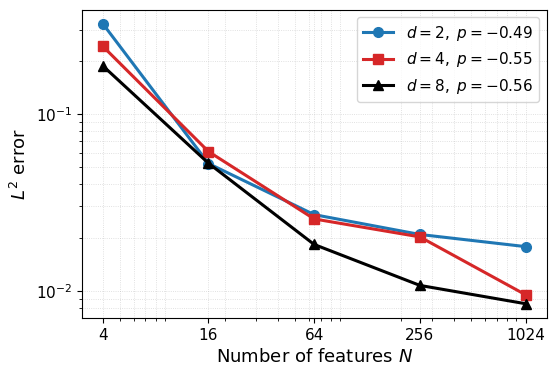

In [10]:
feature_num = 4 ** np.arange(1, 6) 
mean_err_L2_2d = np.mean(L2_err_2d, axis = 1) 
mean_err_H1_2d = np.mean(H1_err_2d, axis = 1) 
mean_err_L2_4d = np.mean(L2_err_4d, axis = 1) 
mean_err_H1_4d = np.mean(H1_err_4d, axis = 1) 
mean_err_L2_8d = np.mean(L2_err_8d, axis = 1) 
mean_err_H1_8d = np.mean(H1_err_8d, axis = 1) 
log_N = np.log(feature_num) 
log_error_L2_2d = np.log(mean_err_L2_2d) 
log_error_H1_2d = np.log(mean_err_H1_2d) 

log_error_L2_4d = np.log(mean_err_L2_4d) 
log_error_H1_4d = np.log(mean_err_H1_4d) 

log_error_L2_8d = np.log(mean_err_L2_8d) 
log_error_H1_8d = np.log(mean_err_H1_8d) 

# Fit line: log(error) = p * log(h) + C
p_L2_2d, C_L2_2d = np.polyfit(log_N, log_error_L2_2d, 1) 
p_H1_2d, C_H1_2d = np.polyfit(log_N, log_error_H1_2d, 1) 

p_L2_4d, C_L2_4d = np.polyfit(log_N, log_error_L2_4d, 1) 
p_H1_4d, C_H1_4d = np.polyfit(log_N, log_error_H1_4d, 1) 

p_L2_8d, C_L2_8d = np.polyfit(log_N, log_error_L2_8d, 1) 
p_H1_8d, C_H1_8d = np.polyfit(log_N, log_error_H1_8d, 1) 


plt.rcParams.update({
    "font.size": 12,
    "axes.labelsize": 13,
    "axes.titlesize": 13,
    "legend.fontsize": 11,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
})

lw = 2.2
ms = 7

 
fig = plt.figure(figsize = (6,4))
ax = plt.subplot(1,1,1)
ax.plot(feature_num, mean_err_L2_2d,
        '-o', color ='tab:blue',
        linewidth = lw, markersize = ms,
        label=rf"$d=2,\ p={p_L2_2d:.2f}$")

ax.plot(feature_num, mean_err_L2_4d,
        '-s', color ='tab:red',
        linewidth=lw, markersize=ms,
        label=rf"$d=4,\ p={p_L2_4d:.2f}$")

ax.plot(feature_num, mean_err_L2_8d,
        '-^', color ='black',
        linewidth=lw, markersize=ms,
        label=rf"$d=8,\ p={p_L2_8d:.2f}$")

ax.set_xscale('log') # logarithmuc scale on x-axis 
ax.set_yscale('log') #  # logarithmic scale on y-axis
ax.set_xticks(feature_num)
ax.set_xticklabels([str(x) for x in feature_num])
ax.set_xlabel(r'Number of features $N$')
ax.set_ylabel(r'$L^2$ error')
ax.legend()
ax.grid(True, which='both',
        linestyle=':',
        linewidth=0.6,
        alpha=0.5)
# ax.grid(color='gray', linestyle='--', linewidth = 0.5)

fig.savefig(
    "Nonlinear_Poisson_L2_Convergence_Rate.pdf",
    bbox_inches='tight'
)
fig.savefig(
    "Nonlinear_Poisson_L2_Convergence_Rate.png",
    dpi=600,
    bbox_inches='tight'
)

# fig.savefig("Nonlinear_Poisson_Convergence_Rate_Gaussian.png", dpi = 300, bbox_inches='tight')

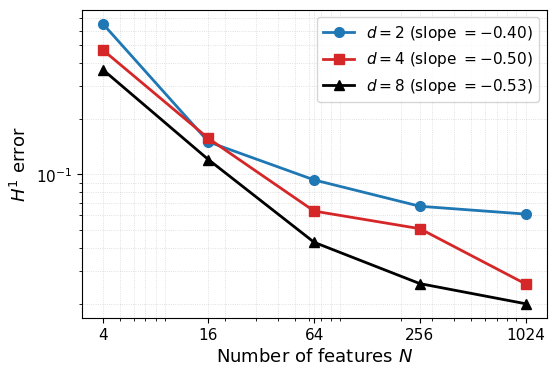

In [12]:
plt.rcParams.update({
    "font.size": 12,
    "axes.labelsize": 13,
    "axes.titlesize": 13,
    "legend.fontsize": 11,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
})

lw = 2.2
ms = 7
 
fig = plt.figure(figsize = (6,4))
ax = plt.subplot(1,1,1)
ax.plot(feature_num, mean_err_H1_2d,
        '-o', color='tab:blue', linewidth=2,
        markersize=7,
        label=rf"$d=2$ (slope $={p_H1_2d:.2f}$)")

ax.plot(feature_num, mean_err_H1_4d,
        '-s', color='tab:red', linewidth=2,
        markersize=7,
        label=rf"$d=4$ (slope $={p_H1_4d:.2f}$)")

ax.plot(feature_num, mean_err_H1_8d,
        '-^', color='black', linewidth=2,
        markersize=7,
        label=rf"$d=8$ (slope $={p_H1_8d:.2f}$)")

ax.set_xscale('log') # logarithmuc scale on x-axis 
ax.set_yscale('log') #  # logarithmic scale on y-axis
ax.set_xticks(feature_num)
ax.set_xticklabels([str(x) for x in feature_num])
ax.set_xlabel(r'Number of features $N$')
ax.set_ylabel(r'$H^{1}$ error')
ax.legend()
ax.grid(True, which='both',
        linestyle=':',
        linewidth=0.6,
        alpha=0.5)

"""
fig.savefig(
    "Nonlinear_Poisson_H1_Convergence_Rate.pdf",
    bbox_inches='tight'
)
fig.savefig(
    "Nonlinear_Poisson_H1_Convergence_Rate.png",
    dpi=600,
    bbox_inches='tight'
)
""" 
